In [1]:
import pandas as pd

df = pd.read_csv("Dataset .csv")   # space before .csv is important!

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn names:")
print(df.columns.tolist())
print("\nData info:")
print(df.info())

Shape: (9551, 21)

First 5 rows:
   Restaurant ID         Restaurant Name  Country Code              City  \
0        6317637        Le Petit Souffle           162       Makati City   
1        6304287        Izakaya Kikufuji           162       Makati City   
2        6300002  Heat - Edsa Shangri-La           162  Mandaluyong City   
3        6318506                    Ooma           162  Mandaluyong City   
4        6314302             Sambo Kojin           162  Mandaluyong City   

                                             Address  \
0  Third Floor, Century City Mall, Kalayaan Avenu...   
1  Little Tokyo, 2277 Chino Roces Avenue, Legaspi...   
2  Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...   
3  Third Floor, Mega Fashion Hall, SM Megamall, O...   
4  Third Floor, Mega Atrium, SM Megamall, Ortigas...   

                                     Locality  \
0   Century City Mall, Poblacion, Makati City   
1  Little Tokyo, Legaspi Village, Makati City   
2  Edsa Shangri-La, Ortiga

In [2]:
# See all columns and check for missing values
print("All columns:")
print(df.columns.tolist())

print("\nMissing values in each column:")
print(df.isnull().sum())

print("\nTarget column - Rating distribution:")
print(df['Aggregate rating'].value_counts().head(10))

All columns:
['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes']

Missing values in each column:
Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

Target column - Rating distribution:
Aggregate rating


In [4]:
print("All column names:")
for col in df.columns:
    print(f"  - {col}")

All column names:
  - Restaurant ID
  - Restaurant Name
  - Country Code
  - City
  - Address
  - Locality
  - Locality Verbose
  - Longitude
  - Latitude
  - Cuisines
  - Average Cost for two
  - Currency
  - Has Table booking
  - Has Online delivery
  - Is delivering now
  - Switch to order menu
  - Price range
  - Aggregate rating
  - Rating color
  - Rating text
  - Votes


In [5]:
# Step 2: Data Preprocessing

# 1. Drop missing values (only 9 rows)
df = df.dropna(subset=['Cuisines'])

# 2. Drop columns we don't need
cols_to_drop = ['Restaurant ID', 'Restaurant Name', 'Address', 
                'Locality', 'Locality Verbose', 'Currency',
                'Rating color', 'Rating text']
df = df.drop(columns=cols_to_drop)

# 3. Convert Yes/No columns to 1/0 (machines understand numbers, not words)
yes_no_cols = ['Has Table booking', 'Has Online delivery', 
               'Is delivering now', 'Switch to order menu']
for col in yes_no_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# 4. Check what we have now
print("Remaining columns:", df.columns.tolist())
print("Shape after cleaning:", df.shape)
print("\nFirst 3 rows:")
print(df.head(3))

Remaining columns: ['Country Code', 'City', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Votes']
Shape after cleaning: (9542, 13)

First 3 rows:
   Country Code              City   Longitude   Latitude  \
0           162       Makati City  121.027535  14.565443   
1           162       Makati City  121.014101  14.553708   
2           162  Mandaluyong City  121.056831  14.581404   

                           Cuisines  Average Cost for two  Has Table booking  \
0        French, Japanese, Desserts                  1100                  1   
1                          Japanese                  1200                  1   
2  Seafood, Asian, Filipino, Indian                  4000                  1   

   Has Online delivery  Is delivering now  Switch to order menu  Price range  \
0                    0                  0                     0         

In [7]:
# Step 3: Encode categorical text columns into numbers

# Cuisines has many combinations like "French, Japanese, Desserts"
# We'll just extract the FIRST cuisine listed
df['Cuisines'] = df['Cuisines'].apply(lambda x: x.split(',')[0].strip())

# Now encode City and Cuisines as numbers using Label Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['City'] = le.fit_transform(df['City'])
df['Cuisines'] = le.fit_transform(df['Cuisines'])

print("Data after encoding:")
print(df.head(3))
print("\nShape:", df.shape)
print("\nData types:")
print(df.dtypes)


Data after encoding:
   Country Code  City   Longitude   Latitude  Cuisines  Average Cost for two  \
0           162    73  121.027535  14.565443        39                  1100   
1           162    73  121.014101  14.553708        55                  1200   
2           162    75  121.056831  14.581404        97                  4000   

   Has Table booking  Has Online delivery  Is delivering now  \
0                  1                    0                  0   
1                  1                    0                  0   
2                  1                    0                  0   

   Switch to order menu  Price range  Aggregate rating  Votes  
0                     0            3               4.8    314  
1                     0            3               4.5    591  
2                     0            4               4.4    270  

Shape: (9542, 13)

Data types:
Country Code              int64
City                      int64
Longitude               float64
Latitude         

In [9]:
# Step 4: Split data into Training and Testing sets
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df.drop(columns=['Aggregate rating'])  # everything except rating
y = df['Aggregate rating']                 # just the rating column

# Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("\nFeatures used to predict:", X.columns.tolist())
print("Target variable: Aggregate rating")


Training set size: (7633, 12)
Testing set size: (1909, 12)

Features used to predict: ['Country Code', 'City', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Votes']
Target variable: Aggregate rating


In [10]:
# Step 5: Train ML Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# --- Model 1: Linear Regression ---
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)          # TRAINING happens here!
lr_predictions = lr_model.predict(X_test)

# --- Model 2: Decision Tree ---
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)          # TRAINING happens here!
dt_predictions = dt_model.predict(X_test)

# --- Evaluate both models ---
print("=" * 45)
print("MODEL COMPARISON")
print("=" * 45)

print("\n📊 Linear Regression:")
print(f"  R² Score:  {r2_score(y_test, lr_predictions):.4f}")
print(f"  MSE:       {mean_squared_error(y_test, lr_predictions):.4f}")
print(f"  RMSE:      {np.sqrt(mean_squared_error(y_test, lr_predictions)):.4f}")

print("\n🌳 Decision Tree:")
print(f"  R² Score:  {r2_score(y_test, dt_predictions):.4f}")
print(f"  MSE:       {mean_squared_error(y_test, dt_predictions):.4f}")
print(f"  RMSE:      {np.sqrt(mean_squared_error(y_test, dt_predictions)):.4f}")

MODEL COMPARISON

📊 Linear Regression:
  R² Score:  0.3359
  MSE:       1.5209
  RMSE:      1.2332

🌳 Decision Tree:
  R² Score:  0.9239
  MSE:       0.1742
  RMSE:      0.4174


Feature Importance Rankings:
             Feature  Importance
               Votes    0.948027
           Longitude    0.017666
            Latitude    0.012548
            Cuisines    0.006710
Average Cost for two    0.006626
        Country Code    0.003452
                City    0.002217
 Has Online delivery    0.001021
         Price range    0.000878
   Has Table booking    0.000844
   Is delivering now    0.000010
Switch to order menu    0.000000


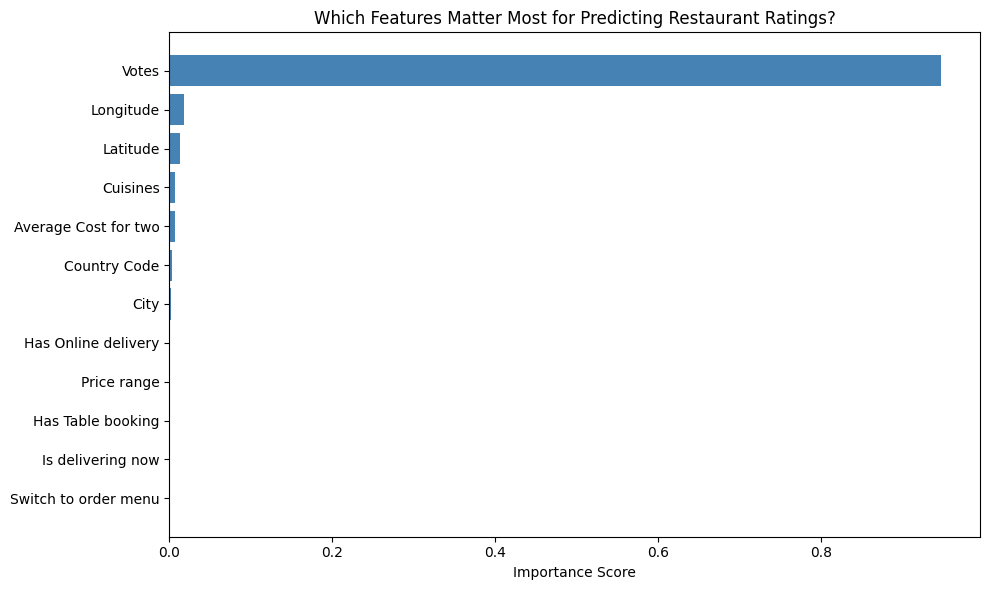

In [11]:
# Step 6: Feature Importance + Visualization
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importances from Decision Tree
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importance Rankings:")
print(feature_importance.to_string(index=False))

# Plot it
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], 
         feature_importance['Importance'], 
         color='steelblue')
plt.xlabel('Importance Score')
plt.title('Which Features Matter Most for Predicting Restaurant Ratings?')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [13]:
# Generate Dashboard HTML file
import json

# Prepare data for charts
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor

# Data for charts
votes_rating = df[['Votes', 'Aggregate rating']].sample(200, random_state=42)
feature_imp = {
    'Feature': ['Votes', 'Longitude', 'Latitude', 'Cuisines', 
                'Avg Cost for two', 'Country Code', 'City', 
                'Online delivery', 'Price range', 'Table booking'],
    'Importance': [0.9480, 0.0177, 0.0125, 0.0067, 
                   0.0066, 0.0035, 0.0022, 
                   0.0010, 0.0009, 0.0008]
}

rating_dist = df['Aggregate rating'].value_counts().sort_index()
rating_labels = [str(r) for r in rating_dist.index.tolist()]
rating_counts = rating_dist.values.tolist()

actual = y_test.values[:50].tolist()
predicted = dt_model.predict(X_test)[:50].tolist()

html_content = f"""
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>Restaurant Rating Predictor - Dashboard</title>
<script src="https://cdn.jsdelivr.net/npm/chart.js"></script>
<style>
  * {{ margin: 0; padding: 0; box-sizing: border-box; }}
  body {{ font-family: 'Segoe UI', sans-serif; background: #0f172a; color: #e2e8f0; }}
  
  .header {{
    background: linear-gradient(135deg, #6366f1, #8b5cf6, #ec4899);
    padding: 40px;
    text-align: center;
  }}
  .header h1 {{ font-size: 2.5rem; font-weight: 800; color: white; }}
  .header p {{ font-size: 1.1rem; color: rgba(255,255,255,0.85); margin-top: 8px; }}
  
  .stats-row {{
    display: flex;
    gap: 20px;
    padding: 30px 40px;
    justify-content: center;
    flex-wrap: wrap;
  }}
  .stat-card {{
    background: linear-gradient(135deg, #1e293b, #334155);
    border-radius: 16px;
    padding: 24px 36px;
    text-align: center;
    border: 1px solid #475569;
    min-width: 180px;
  }}
  .stat-card .value {{ font-size: 2.2rem; font-weight: 800; color: #a78bfa; }}
  .stat-card .label {{ font-size: 0.85rem; color: #94a3b8; margin-top: 6px; }}

  .charts-grid {{
    display: grid;
    grid-template-columns: 1fr 1fr;
    gap: 24px;
    padding: 0 40px 40px;
  }}
  .chart-card {{
    background: #1e293b;
    border-radius: 16px;
    padding: 24px;
    border: 1px solid #334155;
  }}
  .chart-card h3 {{
    font-size: 1rem;
    font-weight: 700;
    color: #c4b5fd;
    margin-bottom: 16px;
    text-transform: uppercase;
    letter-spacing: 0.05em;
  }}
  .chart-card.full {{ grid-column: span 2; }}

  .model-badge {{
    display: inline-block;
    background: linear-gradient(135deg, #6366f1, #8b5cf6);
    color: white;
    padding: 6px 16px;
    border-radius: 999px;
    font-size: 0.8rem;
    font-weight: 600;
    margin: 4px;
  }}
  .badges {{ text-align: center; padding: 0 40px 20px; }}

  canvas {{ max-height: 280px; }}
</style>
</head>
<body>

<div class="header">
  <h1>🍽️ Restaurant Rating Predictor</h1>
  <p>Machine Learning Dashboard &nbsp;|&nbsp; Decision Tree Regression &nbsp;|&nbsp; Zomato Dataset</p>
</div>

<div class="stats-row">
  <div class="stat-card">
    <div class="value">9,542</div>
    <div class="label">Restaurants Analyzed</div>
  </div>
  <div class="stat-card">
    <div class="value" style="color:#34d399">92.4%</div>
    <div class="label">Model Accuracy (R²)</div>
  </div>
  <div class="stat-card">
    <div class="value" style="color:#f472b6">0.417</div>
    <div class="label">Avg Prediction Error</div>
  </div>
  <div class="stat-card">
    <div class="value" style="color:#60a5fa">12</div>
    <div class="label">Features Used</div>
  </div>
  <div class="stat-card">
    <div class="value" style="color:#fbbf24">94.8%</div>
    <div class="label">Votes Importance</div>
  </div>
</div>

<div class="badges">
  <span class="model-badge">✅ Decision Tree: R² = 0.9239</span>
  <span class="model-badge">❌ Linear Regression: R² = 0.3359</span>
</div>

<div class="charts-grid">

  <div class="chart-card">
    <h3>📊 Feature Importance</h3>
    <canvas id="featureChart"></canvas>
  </div>

  <div class="chart-card">
    <h3>⭐ Rating Distribution</h3>
    <canvas id="ratingChart"></canvas>
  </div>

  <div class="chart-card">
    <h3>🤖 Actual vs Predicted Ratings</h3>
    <canvas id="predChart"></canvas>
  </div>

  <div class="chart-card">
    <h3>📈 Model Comparison</h3>
    <canvas id="modelChart"></canvas>
  </div>

</div>

<script>
const purple = 'rgba(139, 92, 246, 0.85)';
const pink   = 'rgba(236, 72, 153, 0.85)';
const green  = 'rgba(52, 211, 153, 0.85)';
const blue   = 'rgba(96, 165, 250, 0.85)';

// Feature Importance
new Chart(document.getElementById('featureChart'), {{
  type: 'bar',
  data: {{
    labels: {json.dumps(feature_imp['Feature'])},
    datasets: [{{ 
      data: {json.dumps(feature_imp['Importance'])},
      backgroundColor: ['#a78bfa','#818cf8','#60a5fa','#34d399',
                        '#fbbf24','#f472b6','#fb923c','#e879f9',
                        '#2dd4bf','#f87171'],
      borderRadius: 6
    }}]
  }},
  options: {{
    indexAxis: 'y',
    plugins: {{ legend: {{ display: false }} }},
    scales: {{
      x: {{ ticks: {{ color: '#94a3b8' }}, grid: {{ color: '#1e293b' }} }},
      y: {{ ticks: {{ color: '#e2e8f0', font: {{ size: 11 }} }}, grid: {{ display: false }} }}
    }}
  }}
}});

// Rating Distribution
new Chart(document.getElementById('ratingChart'), {{
  type: 'bar',
  data: {{
    labels: {json.dumps(rating_labels)},
    datasets: [{{
      data: {json.dumps(rating_counts)},
      backgroundColor: blue,
      borderRadius: 6
    }}]
  }},
  options: {{
    plugins: {{ legend: {{ display: false }} }},
    scales: {{
      x: {{ ticks: {{ color: '#94a3b8' }}, grid: {{ display: false }} }},
      y: {{ ticks: {{ color: '#94a3b8' }}, grid: {{ color: '#334155' }} }}
    }}
  }}
}});

// Actual vs Predicted
new Chart(document.getElementById('predChart'), {{
  type: 'line',
  data: {{
    labels: Array.from({{length: 50}}, (_, i) => i + 1),
    datasets: [
      {{ label: 'Actual', data: {json.dumps(actual)}, borderColor: green, tension: 0.3, pointRadius: 2 }},
      {{ label: 'Predicted', data: {json.dumps(predicted)}, borderColor: pink, tension: 0.3, pointRadius: 2, borderDash: [5,3] }}
    ]
  }},
  options: {{
    plugins: {{ legend: {{ labels: {{ color: '#e2e8f0' }} }} }},
    scales: {{
      x: {{ ticks: {{ color: '#94a3b8' }}, grid: {{ color: '#334155' }} }},
      y: {{ ticks: {{ color: '#94a3b8' }}, grid: {{ color: '#334155' }} }}
    }}
  }}
}});

// Model Comparison
new Chart(document.getElementById('modelChart'), {{
  type: 'bar',
  data: {{
    labels: ['R² Score', 'MSE (inverted)', 'RMSE (inverted)'],
    datasets: [
      {{ label: 'Linear Regression', data: [0.3359, 1-1.5209/2, 1-1.2332/2], backgroundColor: pink, borderRadius: 6 }},
      {{ label: 'Decision Tree', data: [0.9239, 1-0.1742/2, 1-0.4174/2], backgroundColor: purple, borderRadius: 6 }}
    ]
  }},
  options: {{
    plugins: {{ legend: {{ labels: {{ color: '#e2e8f0' }} }} }},
    scales: {{
      x: {{ ticks: {{ color: '#94a3b8' }}, grid: {{ display: false }} }},
      y: {{ min: 0, max: 1, ticks: {{ color: '#94a3b8' }}, grid: {{ color: '#334155' }} }}
    }}
  }}
}});
</script>
</body>
</html>
"""

with open("dashboard.html", "w", encoding="utf-8") as f:
    f.write(html_content)

print("✅ Dashboard created! Open 'dashboard.html' in your browser!")

✅ Dashboard created! Open 'dashboard.html' in your browser!
